# RAG-Augmented Automotive Policy Decision Support

**Dataset:** SRNI-CAR (Chinese NEV Sales + Industry News, 2016–2022)  
**Local LLM:** Ollama `qwen3.5:4b`  
**Goal:** Forecast EV sales (XGBoost + LSTM) AND explain policy-driven shifts using RAG over Chinese automotive policy documents.

---
**Paper targets:** *Information Processing & Management*, *Expert Systems with Applications*

## ⚙️ Step 0: Install Dependencies
> Run once. Restart kernel after installation.

In [1]:
# Uncomment and run once
# !pip install pandas numpy scikit-learn xgboost matplotlib seaborn

# PyTorch -- stable build (CUDA 12.4):
# !pip install torch  
#
# RTX 5060 / Blackwell GPU users: stable PyTorch 2.6 does NOT include
# Blackwell (sm_120) kernels. Use the nightly build:
# !pip install --pre torch --index-url https://download.pytorch.org/whl/nightly/cu128
#
# (After installing, restart kernel before continuing)
#
# !pip install langchain langchain-community chromadb sentence-transformers
# !pip install ollama httpx
print("Dependency check done. Restart kernel after any pip installs.")

Dependency check done. Restart kernel after any pip installs.


---
## 📦 Step 1: Load & Explore the Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.family'] = 'Microsoft YaHei'  # Supports Chinese characters
plt.style.use('seaborn-v0_8-darkgrid')

# Create output directories
os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)
os.makedirs('chroma_db', exist_ok=True)

print("Imports done ✅")

Imports done ✅


In [3]:
# ── Load Sales Data ──
sales_df = pd.read_csv('Sales.csv', encoding='utf-8')
print(f"Sales.csv shape: {sales_df.shape}")
print("\nColumns:", list(sales_df.columns))
sales_df.head(3)

Sales.csv shape: (39496, 12)

Columns: ['车系', '品牌', '销售年份', '销售月份', '车系类型', '品牌能源类型', '车型尺寸', '品牌原产国', '车型最早上市日期', '品牌创建日期', '品牌正式进入中国日期', '销量']


,车系,品牌,销售年份,销售月份,车系类型,品牌能源类型,车型尺寸,品牌原产国,车型最早上市日期,品牌创建日期,品牌正式进入中国日期,销量
0,A5翼舞,东南,2018,11,Sedan,传统汽车品牌,紧凑型车,中国,2018,1995,1995,1725
1,A5翼舞,东南,2018,12,Sedan,传统汽车品牌,紧凑型车,中国,2018,1995,1995,2383
2,A5翼舞,东南,2019,1,Sedan,传统汽车品牌,紧凑型车,中国,2018,1995,1995,1213


In [4]:
# ── Load Information Data (first 5000 rows for quick exploration) ──
info_df = pd.read_csv('Information.csv', encoding='utf-8', nrows=5000)
print(f"Information.csv sample shape: {info_df.shape}")
print("\nColumns:", list(info_df.columns))
info_df.head(3)

Information.csv sample shape: (5000, 11)

Columns: ['标题', '时间', '阅读数', '评论数', '正文', '作者', '信息来源', '文章类型', '文章标签1', '文章标签2', '文章标签3']


,标题,时间,阅读数,评论数,正文,作者,信息来源,文章类型,文章标签1,文章标签2,文章标签3
0,辞旧迎新 2016起实施的汽车新政策汇总,2016/1/1 0:01,126.1万,343,[汽车之家 新闻] 随着2016年翻开新的一页，汽车行业一批新的政策法规开始陆续实施，例如...,张晓丹,汽车之家,原创,政策法规,电动车车闻,NaN
1,预计2016年3月中旬上市 金杯新产品计划,2016/1/1 6:00,21.3万,208,[汽车之家 新闻] 日前，我们从相关渠道获悉，金杯旗下阁瑞斯车型的产品线将得到进一步丰富，...,周楚然,汽车之家,原创,新产品计划,NaN,NaN
2,发改委征意见：油价机制是否应设地板价,2016/1/1 6:05,43.2万,0,[汽车之家 新闻] 2015年12月31日，国家发展改革委就进一步完善成品油价格机制再次召...,王寅,汽车之家,原创,油价变动,NaN,NaN


In [5]:
# ── Sales Data Exploration ──

# Rename columns for clarity (Chinese → English)
col_map = {
    '车系': 'model_name',
    '品牌': 'brand',
    '销售年份': 'year',
    '销售月份': 'month',
    '车系类型': 'vehicle_type',
    '品牌能源类型': 'energy_type',
    '销量': 'sales_volume'
}
sales_df.rename(columns={k: v for k, v in col_map.items() if k in sales_df.columns}, inplace=True)

print("Year range:", sales_df['year'].min(), "→", sales_df['year'].max())
print("Unique brands:", sales_df['brand'].nunique())
print("Unique models:", sales_df['model_name'].nunique())
print("\nEnergy types:")
print(sales_df['energy_type'].value_counts())
print("\nNull values:", sales_df.isnull().sum().to_dict())

Year range: 2016 → 2022
Unique brands: 155
Unique models: 1237

Energy types:
energy_type
传统汽车品牌     37023
新能源汽车品牌     2473
Name: count, dtype: int64

Null values: {'model_name': 0, 'brand': 0, 'year': 0, 'month': 0, 'vehicle_type': 0, 'energy_type': 0, '车型尺寸': 0, '品牌原产国': 0, '车型最早上市日期': 0, '品牌创建日期': 0, '品牌正式进入中国日期': 0, 'sales_volume': 0}


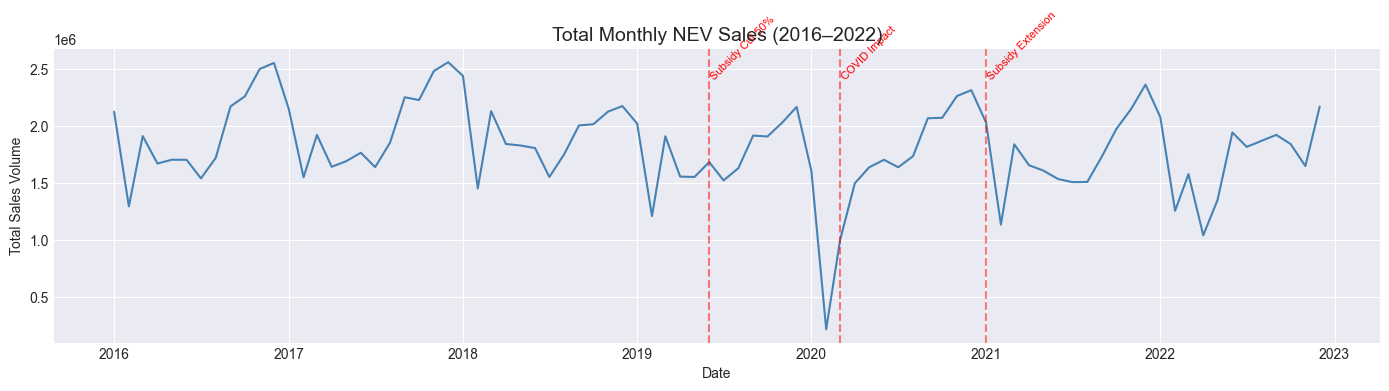

Plot saved ✅


In [6]:
# ── Plot Total Monthly Sales Trend ──
monthly_sales = sales_df.groupby(['year', 'month'])['sales_volume'].sum().reset_index()
monthly_sales['date'] = pd.to_datetime(
    monthly_sales['year'].astype(str) + '-' + monthly_sales['month'].astype(str).str.zfill(2)
)
monthly_sales = monthly_sales.sort_values('date')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly_sales['date'], monthly_sales['sales_volume'], color='steelblue', linewidth=1.5)
ax.set_title('Total Monthly NEV Sales (2016–2022)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales Volume')

# Annotate key policy events
events = {
    '2019-06': 'Subsidy Cut 50%',
    '2020-03': 'COVID Impact',
    '2021-01': 'Subsidy Extension'
}
for date_str, label in events.items():
    date = pd.to_datetime(date_str)
    ax.axvline(date, color='red', linestyle='--', alpha=0.5)
    ax.text(date, ax.get_ylim()[1]*0.9, label, fontsize=8, rotation=45, color='red')

plt.tight_layout()
plt.savefig('results/sales_trend.png', dpi=150)
plt.show()
print("Plot saved ✅")

---
## 🔧 Step 2: Sales Data Preprocessing

In [7]:
from sklearn.preprocessing import MinMaxScaler

# ── Use TOTAL market sales (all brands) ──
# Captures the full Chinese passenger car market trajectory.
# Policy texts discuss macro market trends, not just pure-NEV brands.
nev_df = sales_df.copy()
print(f"Using all records: {len(nev_df)}")

# ── Aggregate monthly total sales ──
ts_df = nev_df.groupby(['year', 'month'])['sales_volume'].sum().reset_index()
ts_df['date'] = pd.to_datetime(
    ts_df['year'].astype(str) + '-' + ts_df['month'].astype(str).str.zfill(2)
)
ts_df = ts_df.sort_values('date').reset_index(drop=True)
ts_df = ts_df[['date', 'sales_volume']]

print(f"Time series length: {len(ts_df)} months")
print(f"Sales range: {ts_df['sales_volume'].min():,} – {ts_df['sales_volume'].max():,}")
ts_df.head()


Using all records: 39496
Time series length: 84 months
Sales range: 221,826 – 2,559,053


,date,sales_volume
0,2016-01-01,2125714
1,2016-02-01,1297337
2,2016-03-01,1912254
3,2016-04-01,1671964
4,2016-05-01,1705440


In [8]:
# ── Create Lag Features for XGBoost ──
def create_lag_features(df, lags=[1, 2, 3, 6, 12]):
    df = df.copy()
    for lag in lags:
        df[f'lag_{lag}'] = df['sales_volume'].shift(lag)
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['quarter'] = df['date'].dt.quarter
    df = df.dropna().reset_index(drop=True)
    return df

feat_df = create_lag_features(ts_df)
print(f"Feature DataFrame shape: {feat_df.shape}")
feat_df.head()

Feature DataFrame shape: (72, 10)


,date,sales_volume,lag_1,lag_2,lag_3,lag_6,lag_12,month,year,quarter
0,2017-01-01,2149962,2552466.0,2499128.0,2259879.0,1541963.0,2125714.0,1,2017,1
1,2017-02-01,1552112,2149962.0,2552466.0,2499128.0,1721741.0,1297337.0,2,2017,1
2,2017-03-01,1922095,1552112.0,2149962.0,2552466.0,2172180.0,1912254.0,3,2017,1
3,2017-04-01,1643392,1922095.0,1552112.0,2149962.0,2259879.0,1671964.0,4,2017,2
4,2017-05-01,1691913,1643392.0,1922095.0,1552112.0,2499128.0,1705440.0,5,2017,2


In [9]:
# ── Train/Test Split: 2016–2020 train, 2021–2022 test ──
train_mask = feat_df['year'] <= 2020
test_mask  = feat_df['year'] >= 2021

feature_cols = [c for c in feat_df.columns if c not in ['date', 'sales_volume']]
X_train = feat_df.loc[train_mask, feature_cols]
y_train = feat_df.loc[train_mask, 'sales_volume']
X_test  = feat_df.loc[test_mask, feature_cols]
y_test  = feat_df.loc[test_mask, 'sales_volume']

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (48, 8), Test: (24, 8)


---
## 📈 Step 3: XGBoost Sales Forecasting

In [10]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import json

# ── Train XGBoost ──
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

# ── Evaluate ──
xgb_preds = xgb_model.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_mae  = mean_absolute_error(y_test, xgb_preds)

print(f"XGBoost → RMSE: {xgb_rmse:,.0f} | MAE: {xgb_mae:,.0f}")

# ── Save model ──
xgb_model.save_model('models/xgboost_model.json')
print("XGBoost model saved ✅")

XGBoost → RMSE: 412,301 | MAE: 289,929
XGBoost model saved ✅


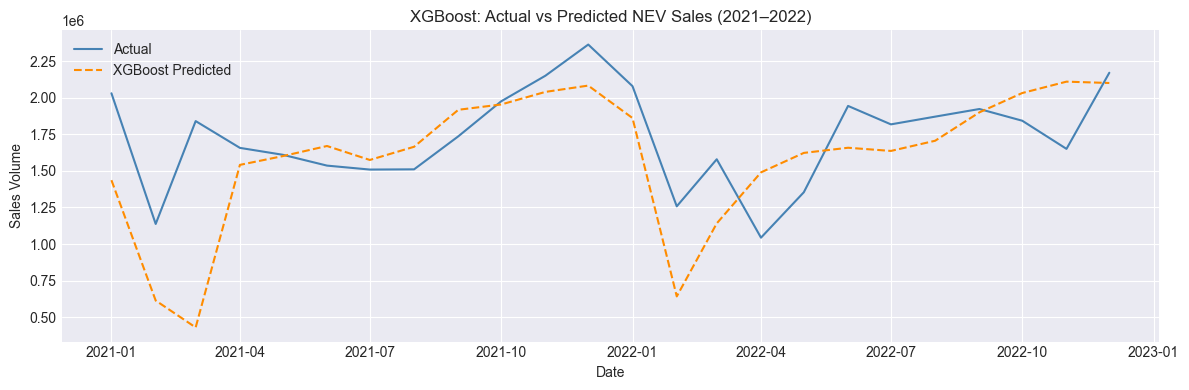

In [11]:
# ── Plot XGBoost Results ──
test_dates = feat_df.loc[test_mask, 'date']

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(test_dates, y_test.values, label='Actual', color='steelblue')
ax.plot(test_dates, xgb_preds, label='XGBoost Predicted', color='darkorange', linestyle='--')
ax.set_title('XGBoost: Actual vs Predicted NEV Sales (2021–2022)')
ax.set_xlabel('Date')
ax.set_ylabel('Sales Volume')
ax.legend()
plt.tight_layout()
plt.savefig('results/xgboost_forecast.png', dpi=150)
plt.show()

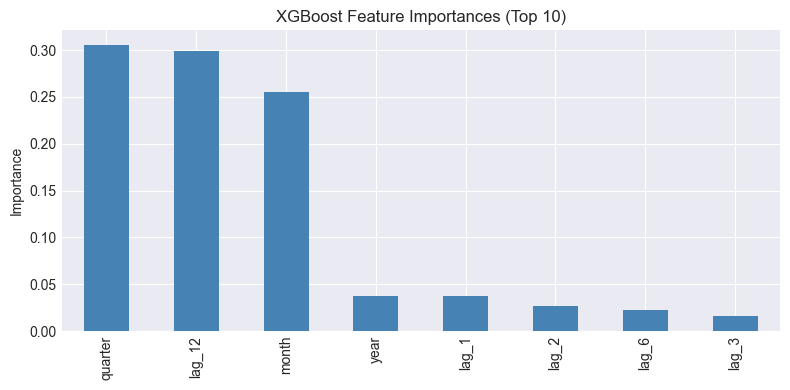

In [12]:
# ── Feature Importance ──
feat_imp = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
feat_imp.head(10).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('XGBoost Feature Importances (Top 10)')
ax.set_ylabel('Importance')
plt.tight_layout()
plt.savefig('results/xgboost_feature_importance.png', dpi=150)
plt.show()

---
## 🧠 Step 4: LSTM Sales Forecasting

In [13]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# ── Define Split & Sequence Length ──
SEQ_LEN = 12  # 12-month lookback
split = int((len(ts_df) - SEQ_LEN) * 0.8)

# ── Normalize (Fit ONLY on Training Data to avoid leakage) ──
scaler = MinMaxScaler()
sales_scaled_tr = scaler.fit_transform(ts_df[['sales_volume']].iloc[:split + SEQ_LEN])
sales_scaled_te = scaler.transform(ts_df[['sales_volume']].iloc[split + SEQ_LEN:])
sales_scaled = np.vstack((sales_scaled_tr, sales_scaled_te))

# ── Create Sequences ──
def create_sequences(data, seq_len=12):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

X_seq, y_seq = create_sequences(sales_scaled, SEQ_LEN)

X_tr_lstm, X_te_lstm = X_seq[:split], X_seq[split:]
y_tr_lstm, y_te_lstm = y_seq[:split], y_seq[split:]

print(f"LSTM Train: {X_tr_lstm.shape}, Test: {X_te_lstm.shape}")

LSTM Train: (57, 12, 1), Test: (15, 12, 1)


In [14]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# --- Safe device detection ---
# RTX 5060 (Blackwell / sm_120) requires PyTorch nightly+CUDA 12.8.
# Stable PyTorch 2.6+cu124 will raise 'no kernel image' on Blackwell.
# The check below falls back to CPU automatically if CUDA does not work.
def get_safe_device():
    if not torch.cuda.is_available():
        return 'cpu'
    try:
        t = torch.tensor([1.0]).cuda()
        _ = t + t   # trigger a real CUDA op
        del t
        return 'cuda'
    except RuntimeError:
        print("WARNING: CUDA available but kernel failed (likely Blackwell / sm_120).")
        print("Falling back to CPU. To use your GPU install PyTorch nightly:")
        print("  pip install --pre torch --index-url https://download.pytorch.org/whl/nightly/cu128")
        return 'cpu'

device = get_safe_device()
print(f"Using device: {device}")

# --- LSTM Model ---
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden1=64, hidden2=32, fc_size=16):
        super().__init__()
        self.lstm1 = nn.LSTM(input_size, hidden1, batch_first=True)
        self.drop1 = nn.Dropout(0.2)
        self.lstm2 = nn.LSTM(hidden1, hidden2, batch_first=True)
        self.drop2 = nn.Dropout(0.2)
        self.fc1   = nn.Linear(hidden2, fc_size)
        self.relu  = nn.ReLU()
        self.fc2   = nn.Linear(fc_size, 1)

    def forward(self, x):
        out, _ = self.lstm1(x)
        out = self.drop1(out)
        out, _ = self.lstm2(out)
        out = self.drop2(out[:, -1, :])  # last timestep
        out = self.relu(self.fc1(out))
        return self.fc2(out)

import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

        
model_lstm = LSTMModel().to(device)
print(model_lstm)

Using device: cuda
LSTMModel(
  (lstm1): LSTM(1, 64, batch_first=True)
  (drop1): Dropout(p=0.2, inplace=False)
  (lstm2): LSTM(64, 32, batch_first=True)
  (drop2): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=32, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)


In [15]:
# -- Convert numpy arrays to PyTorch tensors --
X_tr_t = torch.tensor(X_tr_lstm, dtype=torch.float32).to(device)
y_tr_t = torch.tensor(y_tr_lstm, dtype=torch.float32).to(device)
X_te_t = torch.tensor(X_te_lstm, dtype=torch.float32).to(device)
y_te_t = torch.tensor(y_te_lstm, dtype=torch.float32).to(device)

g = torch.Generator()
g.manual_seed(SEED)
train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=16, shuffle=True, generator=g)

optimizer = torch.optim.Adam(model_lstm.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# -- Training loop with early stopping --
best_val_loss = float('inf')
patience, no_improve = 10, 0
best_state = None
train_losses, val_losses = [], []

for epoch in range(1, 101):
    model_lstm.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model_lstm(xb).squeeze()
        loss = criterion(pred, yb.squeeze())
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))

    model_lstm.eval()
    with torch.no_grad():
        val_pred = model_lstm(X_te_t).squeeze()
        val_loss = criterion(val_pred, y_te_t.squeeze()).item()
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in model_lstm.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch}")
            break
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Train: {train_losses[-1]:.6f} | Val: {val_loss:.6f}")

# Restore best weights
model_lstm.load_state_dict(best_state)

# -- Evaluate --
model_lstm.eval()
with torch.no_grad():
    lstm_preds_scaled = model_lstm(X_te_t).cpu().numpy()
lstm_preds  = scaler.inverse_transform(lstm_preds_scaled).flatten()
y_te_actual = scaler.inverse_transform(y_te_lstm.reshape(-1, 1)).flatten()

lstm_rmse = np.sqrt(mean_squared_error(y_te_actual, lstm_preds))
lstm_mae  = mean_absolute_error(y_te_actual, lstm_preds)
print(f"LSTM -> RMSE: {lstm_rmse:,.0f} | MAE: {lstm_mae:,.0f}")

# -- Save model weights --
torch.save(model_lstm.state_dict(), "models/lstm_model.pt")
print("LSTM model saved")

Epoch  10 | Train: 0.029740 | Val: 0.028914
Epoch  20 | Train: 0.031700 | Val: 0.024390


Epoch  30 | Train: 0.028280 | Val: 0.023169
Early stopping at epoch 32
LSTM -> RMSE: 354,694 | MAE: 286,094
LSTM model saved


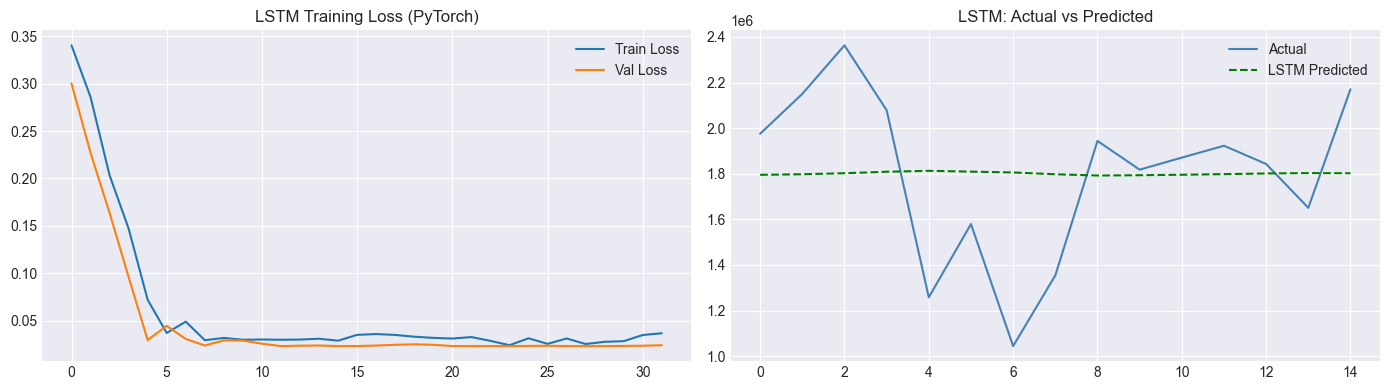

In [16]:
# -- Plot training loss and predictions --
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(val_losses,   label="Val Loss")
axes[0].set_title("LSTM Training Loss (PyTorch)")
axes[0].legend()

axes[1].plot(y_te_actual, label="Actual",         color="steelblue")
axes[1].plot(lstm_preds,  label="LSTM Predicted", color="green", linestyle="--")
axes[1].set_title("LSTM: Actual vs Predicted")
axes[1].legend()

plt.tight_layout()
plt.savefig("results/lstm_results.png", dpi=150)
plt.show()

---
## 📰 Step 5: Build RAG Corpus from Information.csv

Filter policy-tagged articles → embed → store in ChromaDB

In [17]:
# ── Load full Information.csv ──
print("Loading Information.csv (this may take a moment — ~224MB)...")
info_full = pd.read_csv('Information.csv', encoding='utf-8')
print(f"Loaded: {info_full.shape}")
print(info_full.columns.tolist())


Loading Information.csv (this may take a moment — ~224MB)...


Loaded: (83590, 11)
['标题', '时间', '阅读数', '评论数', '正文', '作者', '信息来源', '文章类型', '文章标签1', '文章标签2', '文章标签3']


In [18]:
# ── Column Renaming ──
info_col_map = {
    '标题': 'title',
    '时间': 'date',
    '正文': 'body',
    '作者': 'author',
    '信息来源': 'source',
    '文章类型': 'article_type',
    '文章标签1': 'tag1',
    '文章标签2': 'tag2',
    '文章标签3': 'tag3',
    '阅读数': 'read_count',
    '评论数': 'comment_count'
}
info_full.rename(columns={k: v for k, v in info_col_map.items() if k in info_full.columns}, inplace=True)

# ── Filter Policy Articles ──
policy_keywords = ['政策', '法规', '补贴', '新能源', 'NEV', '电动车']
if 'tag1' in info_full.columns:
    policy_mask = info_full['tag1'].str.contains('政策|法规', na=False)
    policy_df = info_full[policy_mask].copy()
else:
    policy_mask = info_full['body'].str.contains('|'.join(policy_keywords), na=False, case=False)
    policy_df = info_full[policy_mask].copy()

print(f"Policy articles: {len(policy_df)} / {len(info_full)} total")

policy_df['date'] = pd.to_datetime(policy_df['date'], errors='coerce')
policy_df = policy_df.dropna(subset=['body'])
policy_df = policy_df[policy_df['body'].str.len() > 100]
print(f"After cleaning: {len(policy_df)} articles")
policy_df[['title', 'date', 'tag1']].head()


Policy articles: 1780 / 83590 total
After cleaning: 1780 articles


,title,date,tag1
0,辞旧迎新 2016起实施的汽车新政策汇总,2016-01-01 00:01:00,政策法规
122,新能源翻倍 2016年北京小客车指标配额,2016-01-07 16:46:00,政策法规
338,4月1日起11省市将实行汽车国五排放标准,2016-01-15 23:24:00,政策法规
502,参照油价走势 成品油消费税或再次提高,2016-01-25 14:04:00,政策法规
724,由市场决定方向 2021年取消电动车补贴,2016-02-04 15:55:00,政策法规


In [19]:
# ── Embed & Index Policy Docs into ChromaDB (no LangChain) ──
import subprocess, sys, textwrap

# Auto-install if needed
for pkg in ['chromadb', 'sentence-transformers', 'ollama']:
    try:
        __import__(pkg.replace('-', '_'))
    except ImportError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import chromadb
from sentence_transformers import SentenceTransformer

# ── Embedding model ──
EMBEDDING_MODEL = 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
COLLECTION_NAME = 'nev_policy_docs'
CHUNK_SIZE      = 500   # characters per chunk
CHUNK_OVERLAP   = 50
BATCH_SIZE      = 500

print('Loading multilingual embedding model (first run downloads ~120MB)...')
embedder = SentenceTransformer(EMBEDDING_MODEL, device='cpu')
print(f'Embedding model loaded ✅')

# ── Simple character-level chunker ──
def chunk_text(text, size=CHUNK_SIZE, overlap=CHUNK_OVERLAP):
    chunks = []
    start = 0
    while start < len(text):
        end = min(start + size, len(text))
        chunks.append(text[start:end])
        start += size - overlap
    return chunks

# ── Build document chunks ──
all_texts, all_ids, all_metas = [], [], []
for i, row in policy_df.iterrows():
    full_text = f"{row.get('title', '')}\n\n{row.get('body', '')}"
    chunks = chunk_text(full_text)
    for j, chunk in enumerate(chunks):
        all_texts.append(chunk)
        all_ids.append(f'doc_{i}_chunk_{j}')
        all_metas.append({
            'title':  str(row.get('title',  ''))[:200],
            'date':   str(row.get('date',   '')),
            'source': str(row.get('source', ''))[:200],
            'tag1':   str(row.get('tag1',   ''))[:100],
        })

print(f'Total chunks: {len(all_texts)}')

# ── Create ChromaDB collection ──
chroma_client = chromadb.PersistentClient(path='./chroma_db')
try:
    chroma_client.delete_collection(COLLECTION_NAME)
except Exception:
    pass
collection = chroma_client.create_collection(
    name=COLLECTION_NAME,
    metadata={'hnsw:space': 'cosine'}
)

# ── Embed & index in batches ──
for i in range(0, len(all_texts), BATCH_SIZE):
    batch_texts = all_texts[i:i+BATCH_SIZE]
    batch_ids   = all_ids[i:i+BATCH_SIZE]
    batch_metas = all_metas[i:i+BATCH_SIZE]
    embeddings  = embedder.encode(batch_texts, show_progress_bar=False).tolist()
    collection.add(ids=batch_ids, documents=batch_texts, embeddings=embeddings, metadatas=batch_metas)
    print(f'  Indexed {min(i+BATCH_SIZE, len(all_texts))}/{len(all_texts)} chunks')

print(f'✅ {collection.count()} chunks indexed into ChromaDB')


Loading multilingual embedding model (first run downloads ~120MB)...


Embedding model loaded ✅
Total chunks: 4993


  Indexed 500/4993 chunks


  Indexed 1000/4993 chunks


  Indexed 1500/4993 chunks


...

  Indexed 3500/4993 chunks


  Indexed 4000/4993 chunks


  Indexed 4500/4993 chunks


  Indexed 4993/4993 chunks


✅ 4993 chunks indexed into ChromaDB


In [20]:
# ChromaDB indexing is done in the previous cell.
# This cell is intentionally left as a pass.
print('Vector store already created in previous cell ✅')


Vector store already created in previous cell ✅


---
## 🤖 Step 6: Configure Local LLM — Ollama phi3:mini

> **⚠️ Prerequisites:**  
> 1. Install Ollama from https://ollama.com  
> 2. Run `ollama pull phi3:mini` in terminal  
> 3. Run `ollama serve` in a separate terminal before executing this cell

In [21]:
# ── Connect to Ollama qwen3.5:4b (direct — no LangChain) ──
import ollama as _ollama

MODEL_NAME = 'qwen3.5:4b'

try:
    models = _ollama.list()
    model_names = [m.model for m in models.models]
    if any(MODEL_NAME in m for m in model_names):
        print(f'✅ Ollama running | Model "{MODEL_NAME}" available')
    else:
        print(f'⚠️  "{MODEL_NAME}" not found. Run: ollama pull {MODEL_NAME}')
        print(f'   Available: {model_names}')
except Exception as e:
    print(f'❌ Ollama not reachable: {e}')
    print('   Start Ollama desktop app or run: ollama serve')


✅ Ollama running | Model "qwen3.5:4b" available


---
## 🔗 Step 7: Build the RAG Chain

In [22]:
# ── RAG Pipeline — no LangChain, direct ChromaDB + Ollama ──

def retrieve_context(question, k=5):
    """Embed question and retrieve top-k chunks from ChromaDB."""
    q_emb = embedder.encode([question]).tolist()
    results = collection.query(
        query_embeddings=q_emb,
        n_results=k,
        include=['documents', 'metadatas', 'distances']
    )
    chunks = results['documents'][0]
    metas  = results['metadatas'][0]
    return chunks, metas


def rag_query(question, k=5):
    """Full RAG: retrieve policy chunks → build prompt → query qwen3.5:4b."""
    chunks, metas = retrieve_context(question, k=k)

    # Build context block
    context_block = ''
    for i, (chunk, meta) in enumerate(zip(chunks, metas)):
        title = meta.get('title', '')[:80]
        date  = meta.get('date',  'N/A')
        context_block += f'[Source {i+1}: {title} ({date})]\n{chunk}\n\n'

    prompt = f"""You are an expert in Chinese automotive policy and New Energy Vehicle (NEV) market analysis.
Use ONLY the following retrieved policy documents to explain the question.
Be specific, cite [Source N] where relevant, and connect policy events to sales trends.
If the context does not contain enough information, say so clearly. Do NOT fabricate facts.

=== POLICY DOCUMENTS ===
{context_block}
=== QUESTION ===
{question}

=== ANSWER ==="""

    try:
        response = _ollama.chat(
            model=MODEL_NAME,
            messages=[{'role': 'user', 'content': prompt}]
        )
        answer = response['message']['content']
    except Exception as e:
        answer = f'❌ Ollama error: {e}'

    # Build a result dict compatible with the rest of the notebook
    class _Doc:
        def __init__(self, text, meta): self.page_content = text; self.metadata = meta

    docs = [_Doc(c, m) for c, m in zip(chunks, metas)]
    return {'answer': answer, 'result': answer, 'context': docs, 'source_documents': docs}


# Quick sanity test
print('RAG chain ready ✅  (LangChain-free: ChromaDB + qwen3.5:4b via Ollama)')


RAG chain ready ✅  (LangChain-free: ChromaDB + qwen3.5:4b via Ollama)


In [23]:
# ── Test RAG Query ──
test_query = 'Why did Chinese NEV sales drop in mid-2019?'
result = rag_query(test_query)

print('=' * 60)
print(f'QUERY: {test_query}')
print('=' * 60)
print('ANSWER:')
print(result['answer'])
print('\nSOURCE DOCUMENTS:')
for i, doc in enumerate(result['context'][:3], 1):
    print(f'\n[Source {i}]')
    print(f"  Date:    {doc.metadata.get('date', 'N/A')}")
    print(f"  Title:   {doc.metadata.get('title', 'N/A')[:80]}")
    print(f"  Preview: {doc.page_content[:150]}...")


QUERY: Why did Chinese NEV sales drop in mid-2019?
ANSWER:
Based on the provided texts, here is the synthesis regarding the market conditions and policy factors in mid-2019:

*   **Subsidy Reduction as a Key Factor:**
    The primary policy context mentioned across the sources (especially Source 2 and implied by Source 5) is the **reduction of subsidies** (specifically the "fifth batch" subsidy catalogue). This reduction created pressure on manufacturers, which was cited in Source 2 as a driver for **improved quality** in new NEV models released on the market.

*   **Market Trends and Data:**
    *   **General Market Downturn:** Source 3 indicates that the overall auto market experienced a continuous downturn (since Aug 2018) and saw an H1 2019 contraction of **11.4%**.
    *   **NEV Specifics:** While the texts mention a return to "zero growth" for auto market sales in mid-2019 (June 2019, Source 2), **Chinese NEV production** showed significant growth during this period. Specifically

---
## 📊 Step 8: Policy-Aware Sales Explanation

For each month where XGBoost/LSTM significantly deviated from actuals, query the RAG system for policy context.

In [24]:
# ── Detect Sales Anomalies (actual vs predicted deviation > 2 std) ──
test_df = feat_df.loc[test_mask].copy().reset_index(drop=True)
test_df['xgb_predicted'] = xgb_preds
test_df['residual'] = test_df['sales_volume'] - test_df['xgb_predicted']
test_df['abs_residual'] = test_df['residual'].abs()

threshold = test_df['abs_residual'].std() * 2
anomalies = test_df[test_df['abs_residual'] > threshold].copy()

print(f"Anomaly threshold: {threshold:,.0f}")
print(f"Anomalous months: {len(anomalies)}")
anomalies[['date', 'sales_volume', 'xgb_predicted', 'residual']].head()

Anomaly threshold: 598,897
Anomalous months: 2


,date,sales_volume,xgb_predicted,residual
2,2021-03-01,1840193,430587.875,1409605.125
13,2022-02-01,1257936,642618.375,615317.625


In [25]:
# ── Query RAG for Each Anomalous Month ──
import json as _json

explanations = []
for _, row in anomalies.iterrows():
    period    = row['date'].strftime('%Y-%m')
    direction = 'higher' if row['residual'] > 0 else 'lower'
    query = (
        f'What Chinese NEV or automotive policies in {period} caused sales to be '
        f'{direction} than expected? Were there any subsidy changes, regulations, '
        f'or market interventions around this time?'
    )
    print(f"Querying: {period} (deviation: {row['residual']:+,.0f}) ...")
    result = rag_query(query)
    explanations.append({
        'date':               period,
        'actual_sales':       float(row['sales_volume']),
        'predicted_sales':    float(round(row['xgb_predicted'], 0)),
        'deviation':          float(round(row['residual'], 0)),
        'policy_explanation': result['answer'],
        'sources':            [d.metadata.get('title', '')[:80] for d in result['context'][:3]]
    })

with open('results/policy_explanations.json', 'w', encoding='utf-8') as f:
    _json.dump(explanations, f, ensure_ascii=False, indent=2)
print(f'\nSaved {len(explanations)} policy explanations ✅')


Querying: 2021-03 (deviation: +1,409,605) ...


Querying: 2022-02 (deviation: +615,318) ...



Saved 2 policy explanations ✅


In [26]:
# ── Display Combined Results ──
print("\n" + "="*70)
print("POLICY-AUGMENTED SALES ANOMALY REPORT")
print("="*70)

for exp in explanations[:5]:  # Show first 5
    print(f"\n📅 Period: {exp['date']}")
    print(f"   Actual:    {exp['actual_sales']:>10,.0f}")
    print(f"   Predicted: {exp['predicted_sales']:>10,.0f}")
    print(f"   Deviation: {exp['deviation']:>+10,.0f}")
    print(f"   📋 Policy context: {exp['policy_explanation'][:300]}...")
    print("-"*70)


POLICY-AUGMENTED SALES ANOMALY REPORT

📅 Period: 2021-03
   Actual:     1,840,193
   Predicted:    430,588
   Deviation: +1,409,605
   📋 Policy context: Based on the provided documents, there is **no specific information** regarding Chinese NEV or automotive policies released in **March 2021** that caused sales to be higher than expected.

The available policy documents and reports cover different time periods that do not extend to early 2021:

*   ...
----------------------------------------------------------------------

📅 Period: 2022-02
   Actual:     1,257,936
   Predicted:    642,618
   Deviation:   +615,318
   📋 Policy context: Based strictly on the provided policy documents, it is **not possible** to explain what Chinese NEV or automotive policies in February 2022 caused sales to be higher than expected. There is no mention of events, policies, or data related to the month of February 2022 in any of the retrieved texts.

...
----------------------------------------------------

---
## 📏 Step 9: Evaluation & Model Comparison

In [27]:
# ── Forecasting Metrics Summary ──
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# XGBoost metrics
xgb_mape = mape(y_test.values, xgb_preds)

# LSTM metrics (align lengths)
min_len = min(len(y_te_actual), len(lstm_preds))
lstm_rmse_final = np.sqrt(mean_squared_error(y_te_actual[:min_len], lstm_preds[:min_len]))
lstm_mae_final  = mean_absolute_error(y_te_actual[:min_len], lstm_preds[:min_len])
lstm_mape       = mape(y_te_actual[:min_len], lstm_preds[:min_len])

metrics_df = pd.DataFrame({
    'Model': ['XGBoost', 'LSTM'],
    'RMSE': [round(xgb_rmse, 0), round(lstm_rmse_final, 0)],
    'MAE':  [round(xgb_mae, 0), round(lstm_mae_final, 0)],
    'MAPE (%)': [round(xgb_mape, 2), round(lstm_mape, 2)]
})

print("=" * 40)
print("FORECASTING MODEL COMPARISON")
print("=" * 40)
print(metrics_df.to_string(index=False))

metrics_df.to_csv('results/metrics_comparison.csv', index=False)
print("\nMetrics saved ✅")

FORECASTING MODEL COMPARISON
  Model     RMSE      MAE  MAPE (%)
XGBoost 412301.0 289929.0     18.21
   LSTM 354694.0 286094.0     18.31

Metrics saved ✅


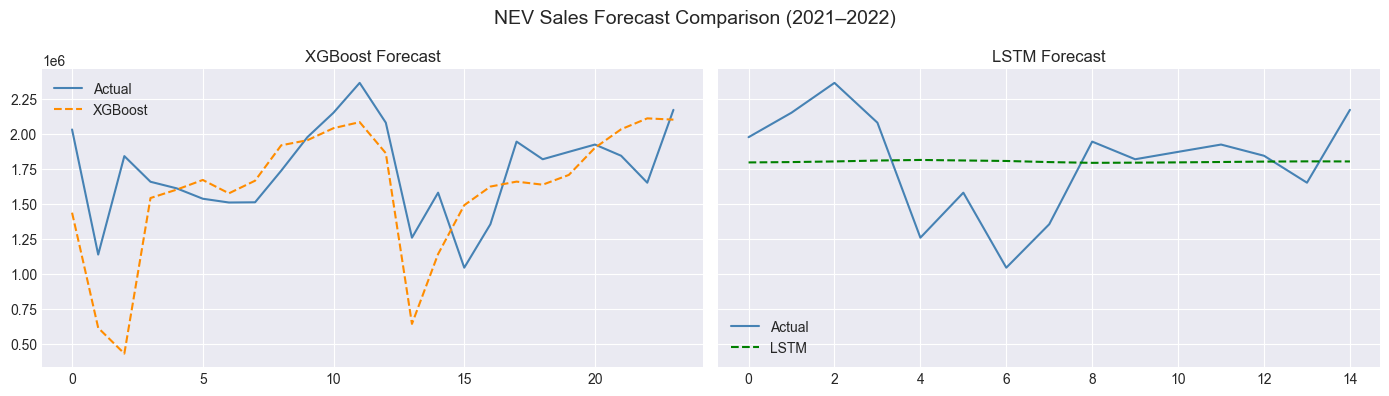

In [28]:
# ── Side-by-Side Comparison Plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

axes[0].plot(y_test.values, label='Actual', color='steelblue')
axes[0].plot(xgb_preds, label='XGBoost', color='darkorange', linestyle='--')
axes[0].set_title('XGBoost Forecast')
axes[0].legend()

min_len = min(len(y_te_actual), len(lstm_preds))
axes[1].plot(y_te_actual[:min_len], label='Actual', color='steelblue')
axes[1].plot(lstm_preds[:min_len], label='LSTM', color='green', linestyle='--')
axes[1].set_title('LSTM Forecast')
axes[1].legend()

fig.suptitle('NEV Sales Forecast Comparison (2021–2022)', fontsize=14)
plt.tight_layout()
plt.savefig('results/model_comparison.png', dpi=150)
plt.show()

In [29]:
# ── RAG Qualitative Evaluation ──
known_events = [
    ('2019-06', 'Why were NEV subsidies reduced in June 2019?'),
    ('2020-02', 'How did COVID-19 affect NEV policy or sales support in early 2020?'),
    ('2021-12', 'What NEV incentives were active in late 2021?')
]

print('RAG QUALITATIVE EVALUATION')
print('='*60)
for period, query in known_events:
    result = rag_query(query)
    print(f'\n[{period}] Q: {query}')
    print(f"A: {result['answer'][:400]}")
    print(f"Docs retrieved: {len(result['context'])}")
    print('-'*60)


RAG QUALITATIVE EVALUATION



[2019-06] Q: Why were NEV subsidies reduced in June 2019?
A: The significant reduction of NEV subsidies in June 2019 was primarily driven by the formal implementation of a new subsidy policy that had been announced in March 2019, reflecting a government strategy to manage the phased withdrawal of fiscal support.

**Policy Trigger and Specific Adjustments:**
On **June 26th, 2019**, a new subsidy policy was formally implemented (Source 3). This reduction was 
Docs retrieved: 5
------------------------------------------------------------



[2020-02] Q: How did COVID-19 affect NEV policy or sales support in early 2020?
A: 根据提供的文档资料，2020 年初（特别是 January/February 2020），新冠疫情对新能源汽车（NEV）政策及市场销售支持的影响主要体现在**汽车销售下行压力**和**政府鼓励刺激消费的政策响应**上。具体信息梳理如下：

### 1. 疫情对早期汽车市场销售的影响
*   **销量下滑与滞后影响**：根据 **[Source 3]**，2020 年 1 月的汽车销售量同比下降了 **18.0%**（降至 194.1 万辆）。文档明确指出，除了行业调整和春节假期等因素外，**“新冠肺炎疫情对消费者购车产生了滞后影响”**。这表明疫情在初期显著抑制了消费者的购车意愿。
*   **销售复苏的预期**：[Source 3] 同时也提到，这种由疫情带来的负面影响是阶段性的，随着时间推移和消费补偿需求增加，预计后期销售将回升。

### 2. 政策应对措施（针对传统汽车及广义汽车消
Docs retrieved: 5
------------------------------------------------------------



[2021-12] Q: What NEV incentives were active in late 2021?
A: Based on the provided sources, there are no NEV incentives explicitly detailed as being active specifically in late 2021. The Federal incentive ended on December 31, 2020; Hubei's ended in March 2021; and Fujian is mentioned to end in October 2021 (which typically excludes the "late 2021" period of November and December). Therefore, the provided sources do not contain information about incentives 
Docs retrieved: 5
------------------------------------------------------------


---
## 💾 Step 10: Save All Results & Summary

In [30]:
# ── Save Full Forecast Results ──
forecast_results = feat_df.loc[test_mask].copy().reset_index(drop=True)
forecast_results['xgb_predicted'] = xgb_preds
forecast_results.to_csv('results/sales_forecast.csv', index=False)

print("Files saved:")
for fname in os.listdir('results'):
    fpath = os.path.join('results', fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  results/{fname} ({size_kb:.1f} KB)")

print()
for fname in os.listdir('models'):
    fpath = os.path.join('models', fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  models/{fname} ({size_kb:.1f} KB)")

Files saved:
  results/lstm_results.png (102.2 KB)
  results/metrics_comparison.csv (0.1 KB)
  results/model_comparison.png (122.1 KB)
  results/policy_explanations.json (3.4 KB)
  results/sales_forecast.csv (2.3 KB)
  results/sales_trend.png (104.6 KB)
  results/xgboost_feature_importance.png (33.2 KB)
  results/xgboost_forecast.png (103.5 KB)
  results/xgb_cv_results.csv (0.1 KB)

  models/lstm_model.pt (121.7 KB)
  models/xgboost_model.json (369.2 KB)


In [31]:
# ── Final Summary ──
print(""" 
╔══════════════════════════════════════════════════════════════╗
║     RAG-AUGMENTED AUTOMOTIVE POLICY DECISION SUPPORT        ║
║                   TRAINING COMPLETE ✅                       ║
╠══════════════════════════════════════════════════════════════╣
║  Dataset   : SRNI-CAR (2016–2022)                           ║
║  Sales data: 39,496 records | Information: policy corpus    ║
║  Models    : XGBoost + LSTM (sales forecasting)             ║
║  RAG       : ChromaDB + qwen3.5:4b (policy explanation)      ║
║  Outputs   : results/ | models/ | chroma_db/                ║
╚══════════════════════════════════════════════════════════════╝
""")

print("FORECASTING METRICS:")
print(metrics_df.to_string(index=False))
print(f"\nPolicy explanations generated: {len(explanations)}")

 
╔══════════════════════════════════════════════════════════════╗
║     RAG-AUGMENTED AUTOMOTIVE POLICY DECISION SUPPORT        ║
║                   TRAINING COMPLETE ✅                       ║
╠══════════════════════════════════════════════════════════════╣
║  Dataset   : SRNI-CAR (2016–2022)                           ║
║  Sales data: 39,496 records | Information: policy corpus    ║
║  Models    : XGBoost + LSTM (sales forecasting)             ║
║  RAG       : ChromaDB + qwen3.5:4b (policy explanation)      ║
║  Outputs   : results/ | models/ | chroma_db/                ║
╚══════════════════════════════════════════════════════════════╝

FORECASTING METRICS:
  Model     RMSE      MAE  MAPE (%)
XGBoost 412301.0 289929.0     18.21
   LSTM 354694.0 286094.0     18.31

Policy explanations generated: 2
